In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

crime = pd.read_csv("data/cleaned_crime_long.csv", parse_dates=["Date"])
london_monthly = crime.groupby("Date")["CrimeCount"].sum().asfreq("MS")

print(london_monthly.shape)
print(london_monthly.index.freq)

(191,)
<MonthBegin>


In [2]:
train = london_monthly[:-12]
test = london_monthly[-12:]

print("Train size:", len(train))
print("Test size:", len(test))
print("Test period:", test.index.min().date(), "to", test.index.max().date())

Train size: 179
Test size: 12
Test period: 2025-03-01 to 2026-02-01


In [3]:
model = ARIMA(train, order=(1, 1, 1))
fitted_model = model.fit()

print(fitted_model.summary())

                               SARIMAX Results                                
Dep. Variable:             CrimeCount   No. Observations:                  179
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1738.513
Date:                Thu, 30 Jul 2026   AIC                           3483.026
Time:                        14:48:12   BIC                           3492.572
Sample:                    04-01-2010   HQIC                          3486.897
                         - 02-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4785      0.371     -1.289      0.198      -1.206       0.249
ma.L1          0.3668      0.382      0.960      0.337      -0.382       1.116
sigma2      1.686e+07   1.75e-08   9.63e+14      0.0

In [4]:
model_simple = ARIMA(train, order=(1, 1, 0))
fitted_simple = model_simple.fit()

print(fitted_simple.summary())

                               SARIMAX Results                                
Dep. Variable:             CrimeCount   No. Observations:                  179
Model:                 ARIMA(1, 1, 0)   Log Likelihood               -1739.068
Date:                Thu, 30 Jul 2026   AIC                           3482.135
Time:                        14:49:44   BIC                           3488.499
Sample:                    04-01-2010   HQIC                          3484.716
                         - 02-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1250      0.025     -5.043      0.000      -0.174      -0.076
sigma2      1.677e+07   9.76e-11   1.72e+17      0.000    1.68e+07    1.68e+07
Ljung-Box (L1) (Q):                   6.01   Jarque-

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

forecast = fitted_simple.forecast(steps=12)

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print("MAE:", mae)
print("RMSE:", rmse)

comparison = pd.DataFrame({"Actual": test, "Forecast": forecast.values})
print(comparison)

MAE: 6217.26044558736
RMSE: 6995.661505225569
            Actual      Forecast
Date                            
2025-03-01   75599  69586.875958
2025-04-01   74357  69524.906965
2025-05-01   78653  69532.651152
2025-06-01   78414  69531.683370
2025-07-01   82509  69531.804313
2025-08-01   77380  69531.789199
2025-09-01   73857  69531.791087
2025-10-01   76963  69531.790851
2025-11-01   76013  69531.790881
2025-12-01   73393  69531.790877
2026-01-01   70305  69531.790878
2026-02-01   67469  69531.790878


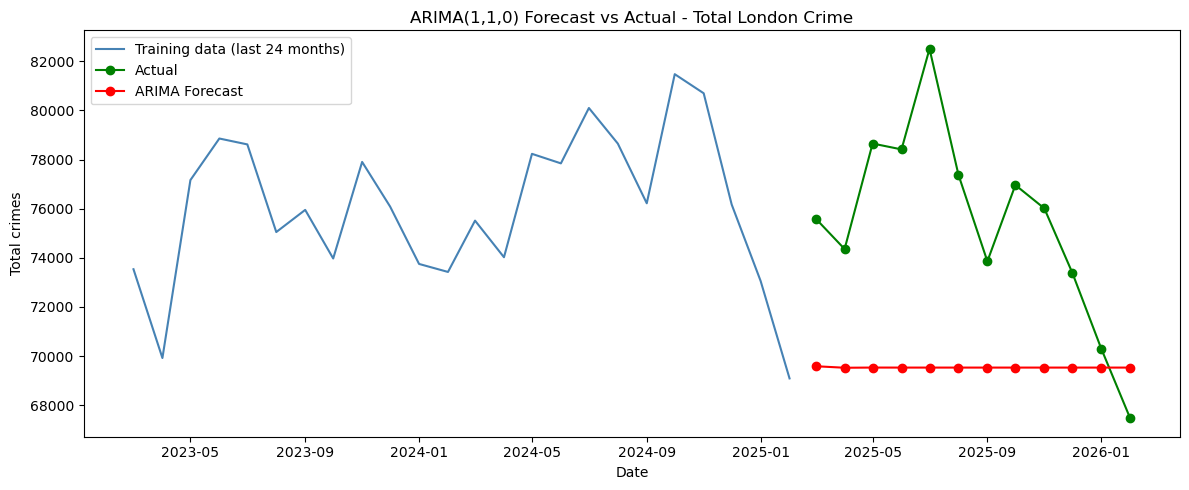

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(train.index[-24:], train.values[-24:], label="Training data (last 24 months)", color="steelblue")
plt.plot(test.index, test.values, label="Actual", color="green", marker="o")
plt.plot(test.index, forecast.values, label="ARIMA Forecast", color="red", marker="o")
plt.title("ARIMA(1,1,0) Forecast vs Actual - Total London Crime")
plt.xlabel("Date")
plt.ylabel("Total crimes")
plt.legend()
plt.tight_layout()
plt.savefig("figures/09_arima_forecast.png", dpi=150)
plt.show()

In [7]:
naive_seasonal_forecast = london_monthly.shift(12)[test.index]

mae_naive_seasonal = mean_absolute_error(test, naive_seasonal_forecast)
rmse_naive_seasonal = np.sqrt(mean_squared_error(test, naive_seasonal_forecast))

print("Naive Seasonal MAE:", mae_naive_seasonal)
print("Naive Seasonal RMSE:", rmse_naive_seasonal)

comparison = pd.DataFrame({
    "Actual": test,
    "ARIMA Forecast": forecast.values,
    "Naive Seasonal": naive_seasonal_forecast.values
})
print(comparison)

Naive Seasonal MAE: 1983.5
Naive Seasonal RMSE: 2481.194907029004
            Actual  ARIMA Forecast  Naive Seasonal
Date                                              
2025-03-01   75599    69586.875958         75514.0
2025-04-01   74357    69524.906965         74024.0
2025-05-01   78653    69532.651152         78233.0
2025-06-01   78414    69531.683370         77845.0
2025-07-01   82509    69531.804313         80099.0
2025-08-01   77380    69531.789199         78650.0
2025-09-01   73857    69531.791087         76220.0
2025-10-01   76963    69531.790851         81476.0
2025-11-01   76013    69531.790881         80699.0
2025-12-01   73393    69531.790877         76170.0
2026-01-01   70305    69531.790878         73059.0
2026-02-01   67469    69531.790878         69091.0


In [8]:
final_comparison = pd.DataFrame({
    "Method": ["ARIMA(1,1,0)", "Naive Seasonal"],
    "MAE": [mae, mae_naive_seasonal],
    "RMSE": [rmse, rmse_naive_seasonal]
})
final_comparison.to_csv("data/arima_comparison.csv", index=False)
print(final_comparison)

           Method          MAE         RMSE
0    ARIMA(1,1,0)  6217.260446  6995.661505
1  Naive Seasonal  1983.500000  2481.194907


In [9]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(train, order=(1, 1, 0), seasonal_order=(1, 1, 0, 12))
fitted_sarima = sarima_model.fit(disp=False)

print(fitted_sarima.summary())

                                     SARIMAX Results                                      
Dep. Variable:                         CrimeCount   No. Observations:                  179
Model:             SARIMAX(1, 1, 0)x(1, 1, 0, 12)   Log Likelihood               -1623.642
Date:                            Thu, 30 Jul 2026   AIC                           3253.284
Time:                                    14:55:04   BIC                           3262.620
Sample:                                04-01-2010   HQIC                          3257.074
                                     - 02-01-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0828      0.091     -0.909      0.363      -0.261       0.096
ar.S.L12      -0.1868      0.017   

In [10]:
sarima_forecast = fitted_sarima.forecast(steps=12)

mae_sarima = mean_absolute_error(test, sarima_forecast)
rmse_sarima = np.sqrt(mean_squared_error(test, sarima_forecast))

print("SARIMA MAE:", mae_sarima)
print("SARIMA RMSE:", rmse_sarima)

comparison = pd.DataFrame({
    "Actual": test,
    "ARIMA": forecast.values,
    "Naive Seasonal": naive_seasonal_forecast.values,
    "SARIMA": sarima_forecast.values
})
print(comparison)

SARIMA MAE: 2126.9839298711813
SARIMA RMSE: 2792.2871287855533
            Actual         ARIMA  Naive Seasonal        SARIMA
Date                                                          
2025-03-01   75599  69586.875958         75514.0  72161.713465
2025-04-01   74357  69524.906965         74024.0  70254.430335
2025-05-01   78653  69532.651152         78233.0  75032.116447
2025-06-01   78414  69531.683370         77845.0  75032.568853
2025-07-01   82509  69531.804313         80099.0  76820.644349
2025-08-01   77380  69531.789199         78650.0  74975.765931
2025-09-01   73857  69531.791087         76220.0  73168.259505
2025-10-01   76963  69531.790851         81476.0  77072.783525
2025-11-01   76013  69531.790881         80699.0  77175.345162
2025-12-01   73393  69531.790877         76170.0  73152.821713
2026-01-01   70305  69531.790878         73059.0  70186.796188
2026-02-01   67469  69531.790878         69091.0  66899.204744


                    Method          MAE         RMSE
0             ARIMA(1,1,0)  6217.260446  6995.661505
1           Naive Seasonal  1983.500000  2481.194907
2  SARIMA(1,1,0)(1,1,0,12)  2126.983930  2792.287129


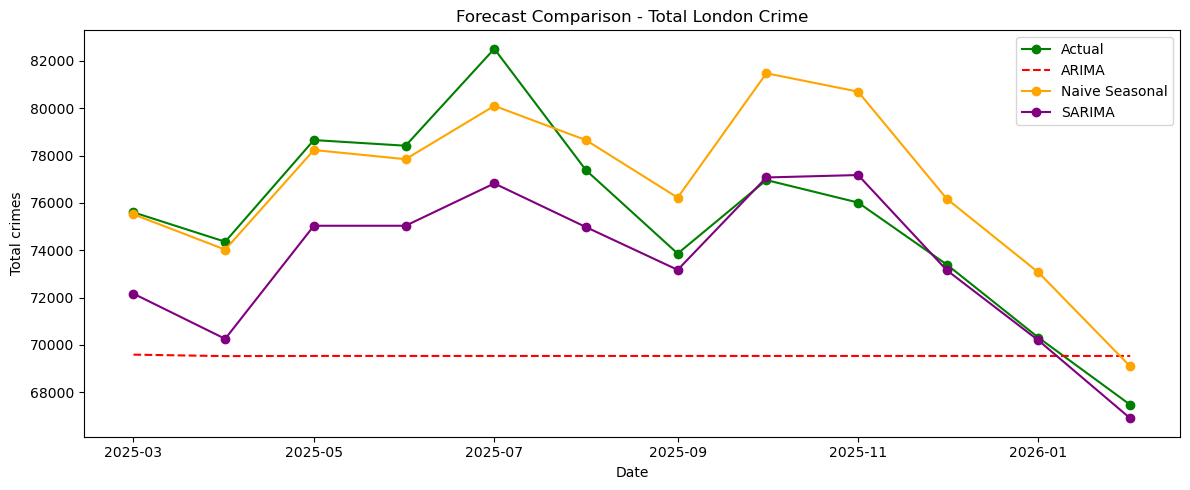

In [11]:
final_comparison = pd.DataFrame({
    "Method": ["ARIMA(1,1,0)", "Naive Seasonal", "SARIMA(1,1,0)(1,1,0,12)"],
    "MAE": [mae, mae_naive_seasonal, mae_sarima],
    "RMSE": [rmse, rmse_naive_seasonal, rmse_sarima]
})
final_comparison.to_csv("data/timeseries_comparison.csv", index=False)
print(final_comparison)

plt.figure(figsize=(12, 5))
plt.plot(test.index, test.values, label="Actual", color="green", marker="o")
plt.plot(test.index, forecast.values, label="ARIMA", color="red", linestyle="--")
plt.plot(test.index, naive_seasonal_forecast.values, label="Naive Seasonal", color="orange", marker="o")
plt.plot(test.index, sarima_forecast.values, label="SARIMA", color="purple", marker="o")
plt.title("Forecast Comparison - Total London Crime")
plt.xlabel("Date")
plt.ylabel("Total crimes")
plt.legend()
plt.tight_layout()
plt.savefig("figures/10_forecast_comparison.png", dpi=150)
plt.show()